<a href="https://colab.research.google.com/github/smousavi05/3D-Machine-Learning/blob/master/EPS210_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: The Data Archaeologist – From Physics to Tensors

**Course:** EPS 210 – AI for Earth and Planetary Science

**Objective:** In this lab, we will translate the "Volume, Velocity, and Variety" of EPS data into the tensor formats required for AI models. We will explore the three dominant data structures discussed in Lecture 1: 1D Time-Series (Seismology), 3D Tensors (Remote Sensing), and 4D Hypercubes (Climate Data).

Prerequisites

You will need the following libraries installed:

In [21]:
!pip install obspy rasterio xarray matplotlib numpy cartopy pystac-client

# Part 1: Seismology – The 1D Time-Series

**Lecture Concept:** Seismograms measure ground motion as a time-series.
Seismograms are sequential data and can be preseted as 1D, 2D, or 3D Tensors.

In this section we use ObsPy (https://docs.obspy.org/master/index.html) to download and process seismograms.

## Task 1: Search for the Event Catalog

**Objective:** Before we can download data, we must define the "Ground Truth."

In seismology, this is the Earthquake Catalog, which provides the time earthquake initiated, its epicenter (the projection of its focal point to the survace) in degrees, and its magnitude (Mw). This corresponds to the "Metadata" layer discussed in the lecture.

In [83]:
import obspy
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import folium  # Standard library for interactive maps in Python

# 1. Initialize Client
client = Client("IRIS")

# 2. Search for the Ridgecrest Event
starttime = UTCDateTime("2019-07-04 00:00:00")
endtime = UTCDateTime("2019-07-07 00:00:00")
min_mag = 7.0

print(f"Searching for events > M{min_mag}...")
catalog = client.get_events(starttime=starttime, endtime=endtime, minmagnitude=min_mag)
print(catalog)

# Select the main event
event = catalog[0]
origin = event.origins[0]
ev_lat = origin.latitude
ev_lon = origin.longitude
ev_mag = event.magnitudes[0].mag

# 3. Create the Map "Plot"
# We center the map on the earthquake location
m = folium.Map(location=[ev_lat, ev_lon], zoom_start=8)

# Add a red marker for the Earthquake
folium.Marker(
    location=[ev_lat, ev_lon],
    popup=f"M{ev_mag} Ridgecrest\nTime: {origin.time.date}",
    icon=folium.Icon(color="red", icon="star"),
    tooltip="Click for Info"
).add_to(m)


print(f"\nSelected Event: M{ev_mag} at {origin.time}")
print("Displaying interactive map below...")

# Display the map
m

Searching for events > M7.0...
1 Event(s) in Catalog:
2019-07-06T03:19:53.040000Z | +35.770, -117.599 | 7.1  mw

Selected Event: M7.1 at 2019-07-06T03:19:53.040000Z
Displaying interactive map below...


## Task 2: Search for Available Stations (Inventory)

**Objective:** We cannot simply download "data"; we must find a sensor that was active and recording at that specific time and location. This step queries the Station Inventory to find sensors within a specific radius of the event.

In [56]:
# Define search radius (degrees) around the epicenter
# 1 degree is approx 111 km
min_radius = 0.0
max_radius = 1.0  # Look for stations within ~110km from the earthquake's epicenter

print(f"Searching for stations within {max_radius} degrees of the epicenter...")

# Network 'CI' is the California Integrated Seismic Network
# Channel 'BH?' means Broadband High-Gain (covers frequencies useful for AI)
inventory = client.get_stations(network="CI", station="*",
                                latitude=origin.latitude, longitude=origin.longitude,
                                minradius=min_radius, maxradius=max_radius,
                                starttime=origin.time, endtime=origin.time+100,
                                level="station") # We only need station names right now

print(f"\nFound {len(inventory.get_contents()['stations'])} candidate stations.")
print(inventory)

Searching for stations within 1.0 degrees of the epicenter...

Found 40 candidate stations.
Inventory created at 2026-01-09T02:20:19.191800Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2019-07-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			CI
		Stations (40):
			CI.APL (Apollo)
			CI.CCA (California City Airport)
			CI.CCC (Christmas Canyon China Lake)
			CI.CGO (Cerro Gordo)
			CI.CLC (China Lake)
			CI.CWC (Cottonwood Creek)
			CI.DAW (Darwin)
			CI.DTP (Desert Tortoise Park)
			CI.EDW2 (Edwards 2)
			CI.FUR (Furnace Creek)
			CI.GSC (Goldstone)
			CI.HAR (Harper Dry Lake bed)
			CI.HYS (Haystack Butte)
			CI.ISA (Isabella)
			CI.JRC2 (Joshua Ridge: China Lake)
			CI.LDR (Leduc Ranch)
			CI.LMR2 (Leuhmann Ridge Extension)
			CI.LRL (Laurel Mtn)
			CI.MPM (Manuel Prospect Mine)
			CI.MRS (Mars)
			CI.Q0056 (Ivy Avenue, Barstow CA)
			CI.Q0065 (Gold Street, Tehachapi CA)
			C

In [84]:
# 2. Add Stations to the previous Map 'm'
# We iterate through the inventory and add a blue marker for each station
for network in inventory:
    for station in network:
        folium.CircleMarker(
            location=[station.latitude, station.longitude],
            radius=5,
            color="blue",
            fill=True,
            fill_color="blue",
            popup=f"{network.code}.{station.code}",
            tooltip=f"Station {station.code}"
        ).add_to(m)
m

## Task 3: Download the Waveforms

**Objective:** Now we retrieve the actual time-series data. In the lecture, we defined this as Sequence Data (1D Tensor). We will request the Vertical (Z), North (N), and East (E) components.

Modern seismometers include 3 elements to determine the simultaneous movement in 3 directions: up-down, north-south,and east-west. Each direction of movement gives information about the earthquake. This animation shows both the movement of the three basic waves (P, S, and surface) and the effect of the waves on a building.

http://youtube.com/watch?v=Za_22xo7ZQQ



In [58]:
# Define the time window relative to the event origin
# We want 30 seconds before the quake and 5 minutes after
t_start = origin.time - 30
t_end = origin.time + 300

print(f"Time Window: {t_start.time} to {t_end.time}\n")

st = None # Initialize empty stream

# We assume 'inventory' was defined in Task 2
if 'inventory' in locals() and len(inventory) > 0:

    # Iterate through every station found in the inventory
    for network in inventory:
        for station in network:

            target_net = network.code
            target_sta = station.code

            print(f"Trying {target_net}.{target_sta}...", end=" ")

            try:
                # Try to get waveforms
                st = client.get_waveforms(network=target_net, station=target_sta,
                                          location="*", channel="BH*",
                                          starttime=t_start, endtime=t_end,
                                          attach_response=True)

                print("SUCCESS!")
                print(f"Downloaded {len(st)} traces.")
                break # We found data! Exit the loop.

            except Exception:
                # If 204 No Data, just print a small 'x' and continue
                print("x (No Data)")

        if st: break # Exit the outer network loop if data is found

else:
    print("No inventory found. Please run Task 2 again.")

if not st:
    print("\nCRITICAL: Tried all stations but found no data.")

Time Window: 03:19:23.040000 to 03:24:53.040000

Trying CI.APL... x (No Data)
Trying CI.CCA... x (No Data)
Trying CI.CCC... x (No Data)
Trying CI.CGO... x (No Data)
Trying CI.CLC... x (No Data)
Trying CI.CWC... SUCCESS!
Downloaded 3 traces.


## Task 4: Visualize Data, Dimensions, and Metadata

**Objective:** Inspect the valid data we just downloaded. This confirms the data matches the 1D Tensor format required for AI models (e.g., RNNs) and visualizes the physics of the quake.

In [63]:
import matplotlib.pyplot as plt
import numpy as np

if 'st' in locals() and st is not None:

    # --- INVENTORY INSPECTION ---
    print(f"Stream contains {len(st)} trace(s):")

    print(st)  # Obspy prints a nice summary list

    print("\nDetailed Component Check:")
    for trace in st:
        # Extract codes: Network.Station.Location.Channel
        net = trace.stats.network
        sta = trace.stats.station
        loc = trace.stats.location
        chan = trace.stats.channel

        # Interpret the Channel Code (SEED convention)
        # Band Code (1st letter): B = Broadband, H = High Broadband
        # Instrument Code (2nd letter): H = Seismometer, N = Accelerometer
        # Orientation (3rd letter): Z = Vertical, N = North, E = East
        print(f" - {net}.{sta}.{loc}.{chan}: {trace.stats.npts} points | {trace.stats.sampling_rate} Hz")

    print("-" * 40)
    # -----------------------------------------

    # 1. Inspect Metadata (The Header)
    # We select the first trace (usually E component) for deep inspection
    tr = st[0]
    print(f"\n--- Deep Dive into Trace: {tr.id} ---")
    print(f"Network: {tr.stats.network} (The operator, e.g., CI = California Integrated)")
    print(f"Station: {tr.stats.station} (The physical site)")
    print(f"Channel: {tr.stats.channel} (The sensor orientation)")
    print(f"Sampling Rate: {tr.stats.sampling_rate} Hz")
    print(f"Data Points (Sequence Length): {tr.stats.npts}")
    print(f"Start Time: {tr.stats.starttime}")
    print(f"End Time: {tr.stats.endtime}")

    # 2. Inspect Dimensions (The Tensor)
    data_tensor = tr.data
    print(f"\nTensor Shape for 1 component (E) ground motion data: {data_tensor.shape} (Time-steps, )")

    # 2b. Inspect the Time Vector
    time_vector = tr.times()
    print(f"Time Vector Shape: {time_vector.shape}")
    print(f"Total Duration: {time_vector[-1]:.2f} seconds")

else:
    print("No data available to visualize.")

Stream contains 3 trace(s):
3 Trace(s) in Stream:
CI.CWC..BHE | 2019-07-06T03:19:23.044538Z - 2019-07-06T03:24:53.019538Z | 40.0 Hz, 13200 samples
CI.CWC..BHN | 2019-07-06T03:19:23.044538Z - 2019-07-06T03:24:53.019538Z | 40.0 Hz, 13200 samples
CI.CWC..BHZ | 2019-07-06T03:19:23.044538Z - 2019-07-06T03:24:53.019538Z | 40.0 Hz, 13200 samples

Detailed Component Check:
 - CI.CWC..BHE: 13200 points | 40.0 Hz
 - CI.CWC..BHN: 13200 points | 40.0 Hz
 - CI.CWC..BHZ: 13200 points | 40.0 Hz
----------------------------------------

--- Deep Dive into Trace: CI.CWC..BHE ---
Network: CI (The operator, e.g., CI = California Integrated)
Station: CWC (The physical site)
Channel: BHE (The sensor orientation)
Sampling Rate: 40.0 Hz
Data Points (Sequence Length): 13200
Start Time: 2019-07-06T03:19:23.044538Z
End Time: 2019-07-06T03:24:53.019538Z

Tensor Shape for 1 component (E) ground motion data: (13200,) (Time-steps, )
Time Vector Shape: (13200,)
Total Duration: 329.98 seconds



Plotting Standard Seismogram (All Components) - 2D Tensor


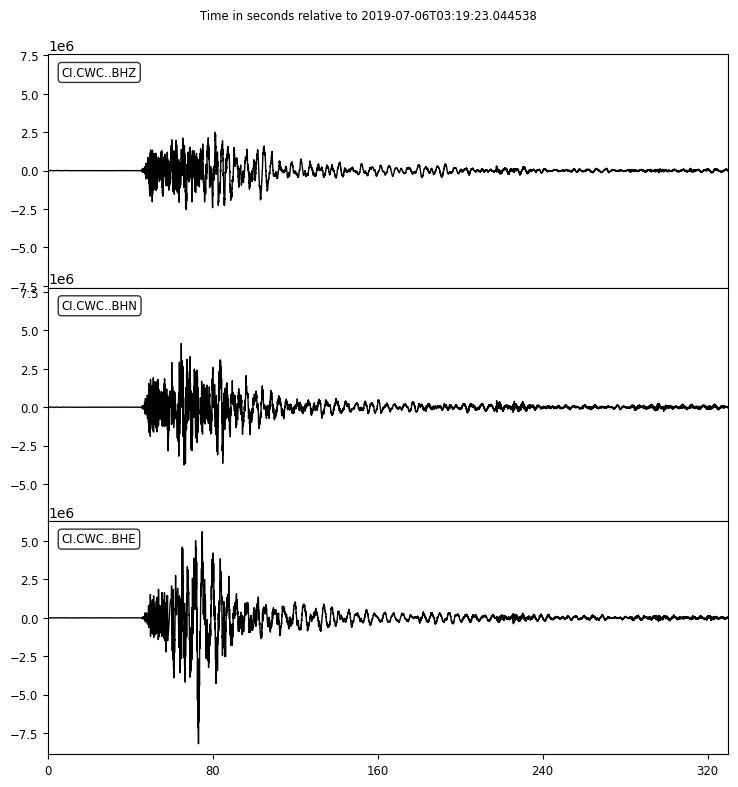

In [70]:
    # 3. Visualization: Time Series
    # apply some preprocessing
    st.detrend("linear")
    st.filter('bandpass',freqmin=0.2, freqmax=10.0)

    print("\nPlotting Standard Seismogram (All Components) - 2D Tensor")
    # This plots Z, N, and E stacked on top of each other
    fig = st.plot(size=(800, 800), type="relative",
            title=f"M{event.magnitudes[0].mag} Ridgecrest Event - {tr.stats.station}")

## 2D and 3D representation of seismograms.

Generating Time-Frequency representation (Spectrogram) for BHE - 2D tensor

Tensor Shape for 1 component (E) time-frequency data: (129, 68)


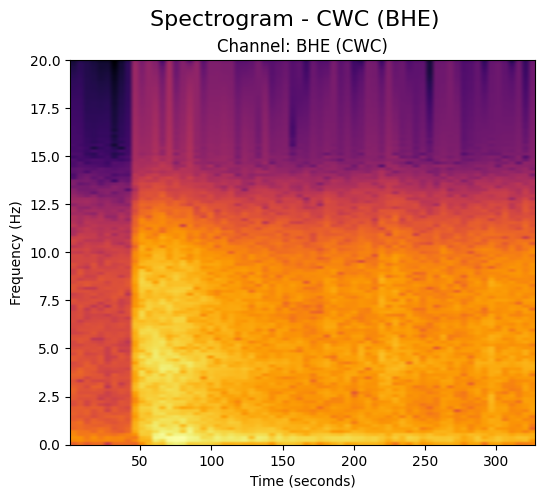

In [77]:
# 4. Visualization: Spectrogram
tr = st[0]
print(f"Generating Time-Frequency representation (Spectrogram) for {tr.stats.channel} - 2D tensor")


fig, ax = plt.subplots(1, 1, figsize=(6, 5))
event_mag = event.magnitudes[0].mag if 'event' in locals() else "Unknown"
fig.suptitle(f"Spectrogram - {tr.stats.station} ({tr.stats.channel})", fontsize=16)

# 3. Plot Spectrogram using Matplotlib's specgram
# NFFT: Window size (256 is standard for seismic)
# Fs: Sampling rate (critical for correct Frequency axis)
# noverlap: Overlap between windows (improves smoothness)
Pxx, freqs, bins, im = ax.specgram(x=tr.data,
                                   NFFT=256,
                                   Fs=tr.stats.sampling_rate,
                                   noverlap=64,
                                   cmap='inferno')

print(f"\nTensor Shape for 1 component (E) time-frequency (STFT) data: {Pxx.shape}")

# 4. Set Metadata & Labels
ax.set_title(f"Channel: {tr.stats.channel} ({tr.stats.station})")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Frequency (Hz)")
plt.show()

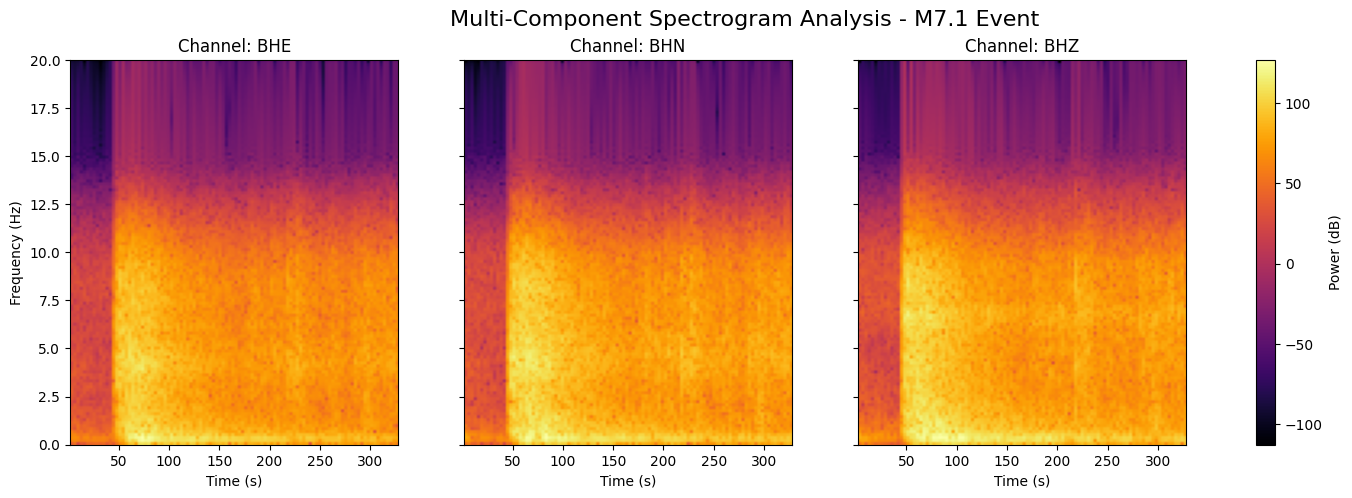


AI DATA PREPARATION COMPLETE
Number of Components Processed: 3
2D Spectrogram Shape (Single):  (129, 102) (Freq x Time)
3D Tensor Shape (Final):        (129, 102, 3) (Freq x Time x Channels)
Data Type:                      float64
This 3D array is now ready to be input into a CNN model.


In [78]:
import matplotlib.pyplot as plt
import numpy as np

if 'st' in locals() and st is not None:
    # 1. Setup the Figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    event_mag = event.magnitudes[0].mag if 'event' in locals() else "Unknown"
    fig.suptitle(f"Multi-Component Spectrogram Analysis - M{event_mag} Event", fontsize=16)

    # Initialize a list to store the 2D spectrogram (Pxx) matrices
    pxx_list = []

    # 2. Loop through each trace
    for i, tr in enumerate(st):
        if i >= 3: break

        ax = axes[i]

        # 3. Compute & Plot
        Pxx, freqs, bins, im = ax.specgram(x=tr.data,
                                           NFFT=256,
                                           Fs=tr.stats.sampling_rate,
                                           noverlap=128,
                                           cmap='inferno')

        pxx_list.append(Pxx)

        # Labels
        ax.set_title(f"Channel: {tr.stats.channel}")
        ax.set_xlabel("Time (s)")
        if i == 0: ax.set_ylabel("Frequency (Hz)")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), label='Power (dB)')
    plt.show()

    # 4. Concatenate into 3D Tensor
    # We stack along a new 3rd axis (Depth) representing the channels (Z, N, E)
    if len(pxx_list) > 0:
        # Stack 2D arrays (Freq, Time) -> 3D array (Freq, Time, Channels)
        spectrogram_tensor = np.dstack(pxx_list)

        print("\n" + "="*40)
        print("AI DATA PREPARATION COMPLETE")
        print("="*40)
        print(f"Number of Components Processed: {len(pxx_list)}")
        print(f"2D Spectrogram Shape (Single):  {pxx_list[0].shape} (Freq x Time)")
        print(f"3D Tensor Shape (Final):        {spectrogram_tensor.shape} (Freq x Time x Channels)")
        print(f"Data Type:                      {spectrogram_tensor.dtype}")
        print("="*40)
        print("This 3D array is now ready to be input into a CNN model.")

else:
    print("No data available.")

**Discussion Question:** Look at the plot. Can you identify the arrival of the P-wave (primary, arrives first) and the S-wave (secondary, larger amplitude)? How would an AI model distinguish these patterns compared to background noise?

----------------------------------------------------


# Part 2: Remote Sensing – The 3D Tensor

**Lecture Concept:** Satellite imagery is not just a "picture"; it is a 3D Tensor of dimensions (Height \times Width \times Bands). We calculate indices like NDVI (Normalized Difference Vegetation Index) using specific spectral bands .

**Task:** We will simulate a multi-spectral satellite image (similar to Sentinel-2) to understand the tensor structure and perform matrix operations.

## Task 1: The Data Hunt (Search & Discovery)

**Objective:** Instead of downloading a massive zip file, we will query a STAC (SpatioTemporal Asset Catalog) to find a specific satellite scene that meets our scientific criteria (low cloud cover, specific date, specific location).


**Key Concept:** This demonstrates how to handle the "Variety" and "Volume" of data by using metadata to filter petabytes of archives down to a single relevant scene .

In [85]:
import pystac_client

# 1. Connect to the Archive
# We use the "Earth Search" STAC API, which indexes public AWS data.
STAC_URL = "https://earth-search.aws.element84.com/v1"
client = pystac_client.Client.open(STAC_URL)

print("Connected to Earth Search STAC API.")

# 2. Define Scientific Criteria
# Region: California Central Valley (Agricultural Zone)
bbox = [-121.5, 38.5, -121.4, 38.6]

# Time: Peak growing season (Summer 2023)
date_range = "2023-06-01/2023-08-30"

# Quality: Less than 5% cloud cover (Crucial for optical sensors)
cloud_cover = {"lt": 5}

print(f"\nSearching for Sentinel-2 scenes in California...")
print(f"Criteria: {date_range}, Clouds < 5%")

# 3. Execute Search
search = client.search(
    collections=["sentinel-2-l2a"], # Level 2A = Surface Reflectance (Atmospherically Corrected)
    bbox=bbox,
    datetime=date_range,
    query={"eo:cloud_cover": cloud_cover}
)

# 4. Inspect Results
items = search.item_collection()
print(f"\nFound {len(items)} scenes matching criteria.")

if len(items) > 0:
    # Select the first (most recent) scene
    selected_scene = items[0]
    print(f"\n--- Selected Scene Metadata ---")
    print(f"ID: {selected_scene.id}")
    print(f"Date: {selected_scene.datetime}")
    print(f"Cloud Cover: {selected_scene.properties['eo:cloud_cover']}%")
    print(f"Platform: {selected_scene.properties['platform']}")

    # Store the Asset URLs for Task 2
    # Sentinel-2 Bands: Red (B04), Green (B03), Blue (B02), NIR (B08)
    assets = selected_scene.assets
    band_urls = {
        "red": assets["red"].href,
        "green": assets["green"].href,
        "blue": assets["blue"].href,
        "nir": assets["nir"].href
    }
    print(f"\nData URL (Red Band): {band_urls['red']}")
    print("(We will stream data from this URL in Task 2)")

else:
    print("No scenes found. Try widening your search criteria.")

Connected to Earth Search STAC API.

Searching for Sentinel-2 scenes in California...
Criteria: 2023-06-01/2023-08-30, Clouds < 5%

Found 14 scenes matching criteria.

--- Selected Scene Metadata ---
ID: S2A_10SFH_20230827_0_L2A
Date: 2023-08-27 19:03:57.394000+00:00
Cloud Cover: 0.001171%
Platform: sentinel-2a

Data URL (Red Band): https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/10/S/FH/2023/8/S2A_10SFH_20230827_0_L2A/B04.tif
(We will stream data from this URL in Task 2)


## Task 2: Streaming & Tensor Construction (Analysis).

**Objective:** Now we perform the "Scientific AI" work. We will stream a small 1000x1000 pixel window directly from the cloud (without downloading the full file), stack the bands into a 3D Tensor, and calculate the NDVI vegetation index.

**Key Concept:** This reinforces the "3D Tensor" structure of remote sensing data $(Height \times Width \times Bands)$ and the physical "Business Logic" of using spectral bands to measure vegetation health .

In [86]:
import rasterio
from rasterio.windows import Window
import numpy as np
import matplotlib.pyplot as plt

# Helper function to stream a specific 'Window' of pixels
# This prevents us from downloading the entire 800MB+ GeoTIFF
def stream_window(url, size=1000):
    with rasterio.open(url) as src:
        # Calculate the center of the image
        center_x = src.width // 2
        center_y = src.height // 2
        # Define the window (subset)
        window = Window(center_x, center_y, size, size)
        # Read the data into a numpy array
        return src.read(1, window=window)

if 'band_urls' in locals():
    print("Streaming data from AWS (this may take a moment)...")

    # 1. Stream the 4 key bands into memory
    # We are creating the "Volume" challenge solution: Intelligent Streaming
    red = stream_window(band_urls["red"])
    green = stream_window(band_urls["green"])
    blue = stream_window(band_urls["blue"])
    nir = stream_window(band_urls["nir"])

    # 2. Build the 3D Tensor
    # Stack 2D arrays -> 3D Tensor (Height, Width, Bands)
    # Order: Red, Green, Blue, NIR
    image_tensor = np.dstack((red, green, blue, nir))

    print(f"\nTensor Constructed!")
    print(f"Shape: {image_tensor.shape} (Height, Width, Bands)")

    # 3. Scientific Analysis: NDVI Calculation
    # Formula: (NIR - Red) / (NIR + Red)
    # We convert to float to allow decimal values
    nir_data = image_tensor[:, :, 3].astype(float)
    red_data = image_tensor[:, :, 0].astype(float)

    # Add epsilon to avoid division by zero errors
    epsilon = 1e-10
    ndvi = (nir_data - red_data) / (nir_data + red_data + epsilon)

else:
    print("Please run Task 1 first to define 'band_urls'.")

Streaming data from AWS (this may take a moment)...

Tensor Constructed!
Shape: (1000, 1000, 4) (Height, Width, Bands)


## Task 3: Visualization

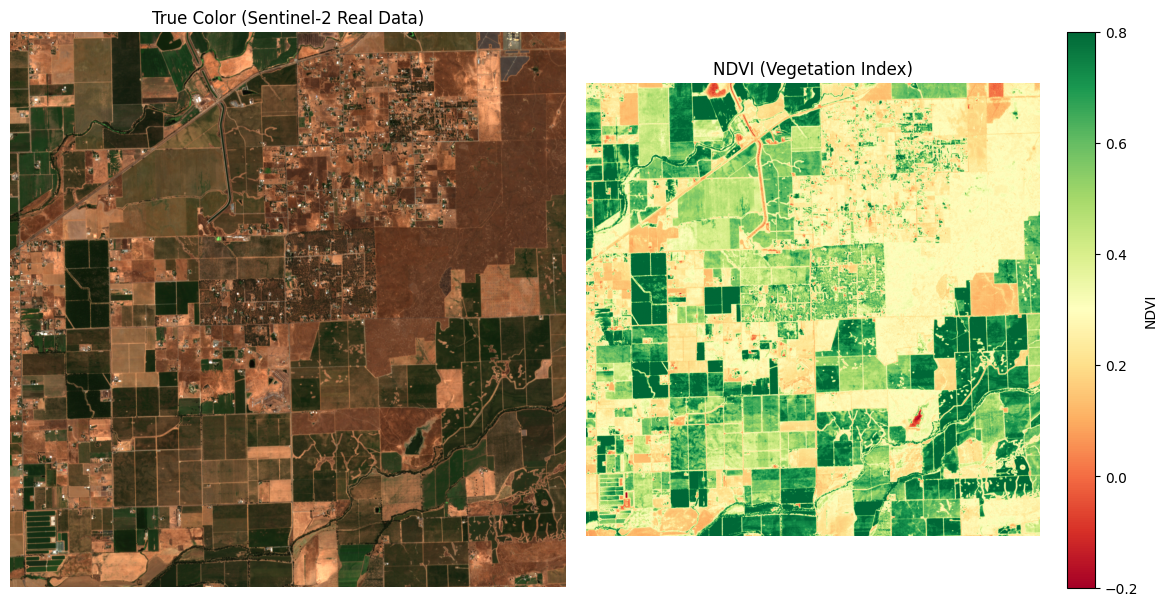

In [87]:
plt.figure(figsize=(12, 6))

# A. True Color Composite (RGB)
# Sentinel-2 data is 16-bit (0-10000+), so we normalize to 0-1 for display
rgb = image_tensor[:, :, :3].astype(float)
rgb_normalized = np.clip(rgb / 3000, 0, 1) # Divide by 3000 to brighten image

plt.subplot(1, 2, 1)
plt.imshow(rgb_normalized)
plt.title("True Color (Sentinel-2 Real Data)")
plt.axis('off')

# B. NDVI Calculation
# Formula: (NIR - Red) / (NIR + Red)
# Note: We use floats to avoid integer division issues
nir_band = image_tensor[:, :, 3].astype(float)
red_band = image_tensor[:, :, 0].astype(float)

epsilon = 1e-10 # Prevent division by zero
ndvi = (nir_band - red_band) / (nir_band + red_band + epsilon)

plt.subplot(1, 2, 2)
# Green = Healthy Vegetation, Brown = Soil/Dead
im = plt.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
plt.colorbar(im, label="NDVI")
plt.title("NDVI (Vegetation Index)")
plt.axis('off')

plt.tight_layout()
plt.show()

**Discussion Question:** Notice how the "Forest" area pops out in green in the NDVI plot, while the "River" is red/negative. Why is the 4th dimension (NIR) critical for this task?

--------------------------------------------------

# Part 3: Climate Science – The 4D Hypercube

**Lecture Concept:** Climate data (like CMIP6 or ERA5) is often stored in NetCDF formats. These represent 4D Tensors: (Time \times Level \times Latitude \times Longitude).

**Task:** We will use xarray to create a synthetic climate dataset and practice "slicing" this hypercube—a crucial skill for preparing data for AI forecasting models.

--- The 4D Climate Tensor ---
<xarray.DataArray 'temperature' (time: 10, level: 3, lat: 50, lon: 60)> Size: 720kB
array([[[[322.24583731, 247.53447038, 237.42740098, ..., 250.74497362,
          274.08012386, 241.20566896],
         [273.24964908, 292.91022857, 260.12886644, ..., 277.80715503,
          325.67917686, 244.92153836],
         [253.61835911, 294.07021575, 289.95059586, ..., 281.93986603,
          241.98654753, 278.29842908],
         ...,
         [293.41893408, 266.08878511, 230.08444068, ..., 283.7044966 ,
          270.76725394, 275.54192453],
         [266.16920466, 266.62140574, 289.58561049, ..., 261.05579149,
          263.01070464, 252.60747587],
         [229.27859707, 272.85442822, 249.39737698, ..., 260.08728175,
          309.26670118, 264.27602128]],

        [[252.58538469, 259.94022308, 286.75406489, ..., 279.7046839 ,
          270.96914589, 301.01378467],
         [287.65068614, 296.91549091, 289.59195277, ..., 230.62514997,
          261.11696144, 266.3

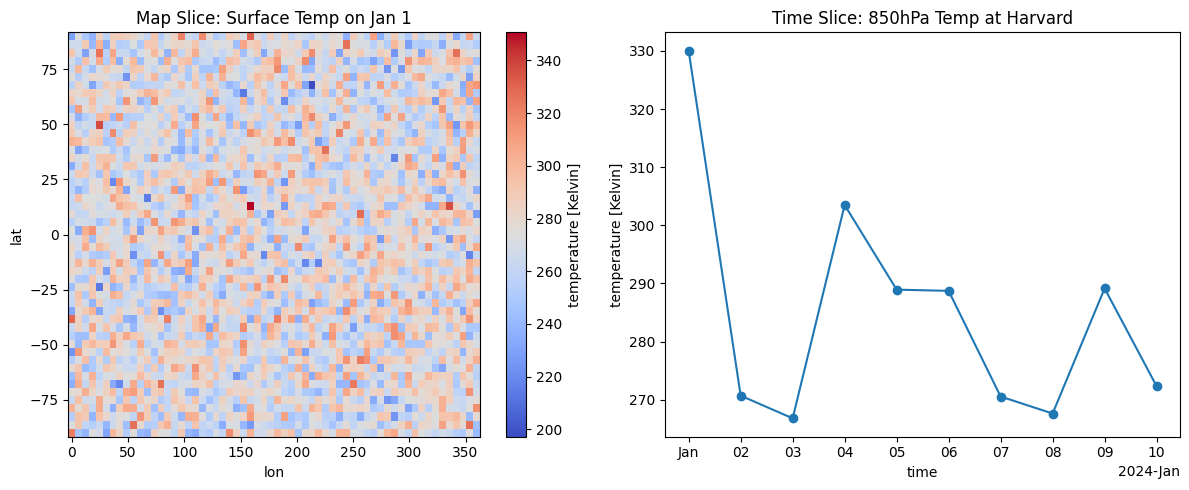

In [4]:
import xarray as xr
import pandas as pd
import numpy as np

# 1. Create Synthetic Climate Data (4D Tensor)
# Define dimensions
times = pd.date_range("2024-01-01", periods=10, freq="D") # 10 Days
levels = [1000, 850, 500] # Pressure levels (hPa)
lats = np.linspace(-90, 90, 50)
lons = np.linspace(0, 360, 60)

# Generate random temperature data (in Kelvin)
data = 273 + 20 * np.random.randn(len(times), len(levels), len(lats), len(lons))

# Create Xarray DataArray (The Standard for Climate AI)
temperature = xr.DataArray(
    data,
    coords={"time": times, "level": levels, "lat": lats, "lon": lons},
    dims=("time", "level", "lat", "lon"),
    name="temperature",
    attrs={"units": "Kelvin", "description": "Synthetic Global Temperature"}
)

print("--- The 4D Climate Tensor ---")
print(temperature)

# 2. Slicing the Hypercube
# Operation A: Select a specific day and pressure level (Map View)
map_view = temperature.sel(time="2024-01-01", level=1000)

# Operation B: Select a specific location (Time-Series View)
# Let's pick a point near Harvard (approx 42N, 71W -> 289E)
ts_view = temperature.sel(level=850, lat=42, lon=289, method="nearest")

# 3. Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Map
plt.subplot(1, 2, 1)
map_view.plot(cmap="coolwarm")
plt.title("Map Slice: Surface Temp on Jan 1")

# Plot Time Series
plt.subplot(1, 2, 2)
ts_view.plot(marker='o')
plt.title("Time Slice: 850hPa Temp at Harvard")

plt.tight_layout()
plt.show()

Discussion Question: In the code above, we accessed data using physical labels (e.g., level=1000) rather than array indices (e.g., array[0]). Why is metadata-aware slicing (as provided by Xarray) safer for scientific AI than treating everything as a raw NumPy array?